# Convert Raw Dumps to Structured HDF5 File

## Imports

In [ ]:
import os
import time
global notebook
notebook = 1

dir = os.getenv('HOME')+'/bh/harm2d'
os.chdir(dir)

import yaml
with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)

%run -i setup.py build_ext --inplace
%run -i pp.py build_ext --inplace
%matplotlib inline
import matplotlib
print('Imports done.')

## Set Relevant Settings

In [ ]:
global notebook, axisym,set_cart,axisym,REF_1,REF_2,REF_3,set_cart,D,print_fieldlines
global lowres1,lowres2,lowres3, RAD_M1, RESISTIVE, export_raytracing_GRTRANS, export_raytracing_RAZIEH,r1,r2,r3
global r_min, r_max, theta_min, theta_max, phi_min,phi_max, do_griddata, do_box, check_files, kerr_schild

dir = '/pscratch/sd/l/lalakos/ml_data_rc300/reduced'
os.chdir(dir)

# set params
lowres1 = 1
lowres2 = 1
lowres3 = 1

do_box=0
r_min=1.0
r_max=100.0
theta_min=0.0
theta_max=9
phi_min=-1
phi_max=9
axisym=1
print_fieldlines=0
export_raytracing_GRTRANS=0
export_raytracing_RAZIEH=0
kerr_schild=0
DISK_THICKNESS=0.03
set_cart=0
set_mpi(0)
check_files=1
notebook=1
interpolate_var=0
AMR = 0 # get all data in grid

## Check that Dumps Can be Read and Viewed

In [ ]:
dir = '/pscratch/sd/l/lalakos/ml_data_rc300/reduced'
os.chdir(dir)

dump = 4000
dumps_path = '/pscratch/sd/l/lalakos/ml_data_rc300/reduced'

#
rblock_new(dump)
rpar_new(dump)
rgdump_griddata(dumps_path)
rdump_griddata(dumps_path, dump)


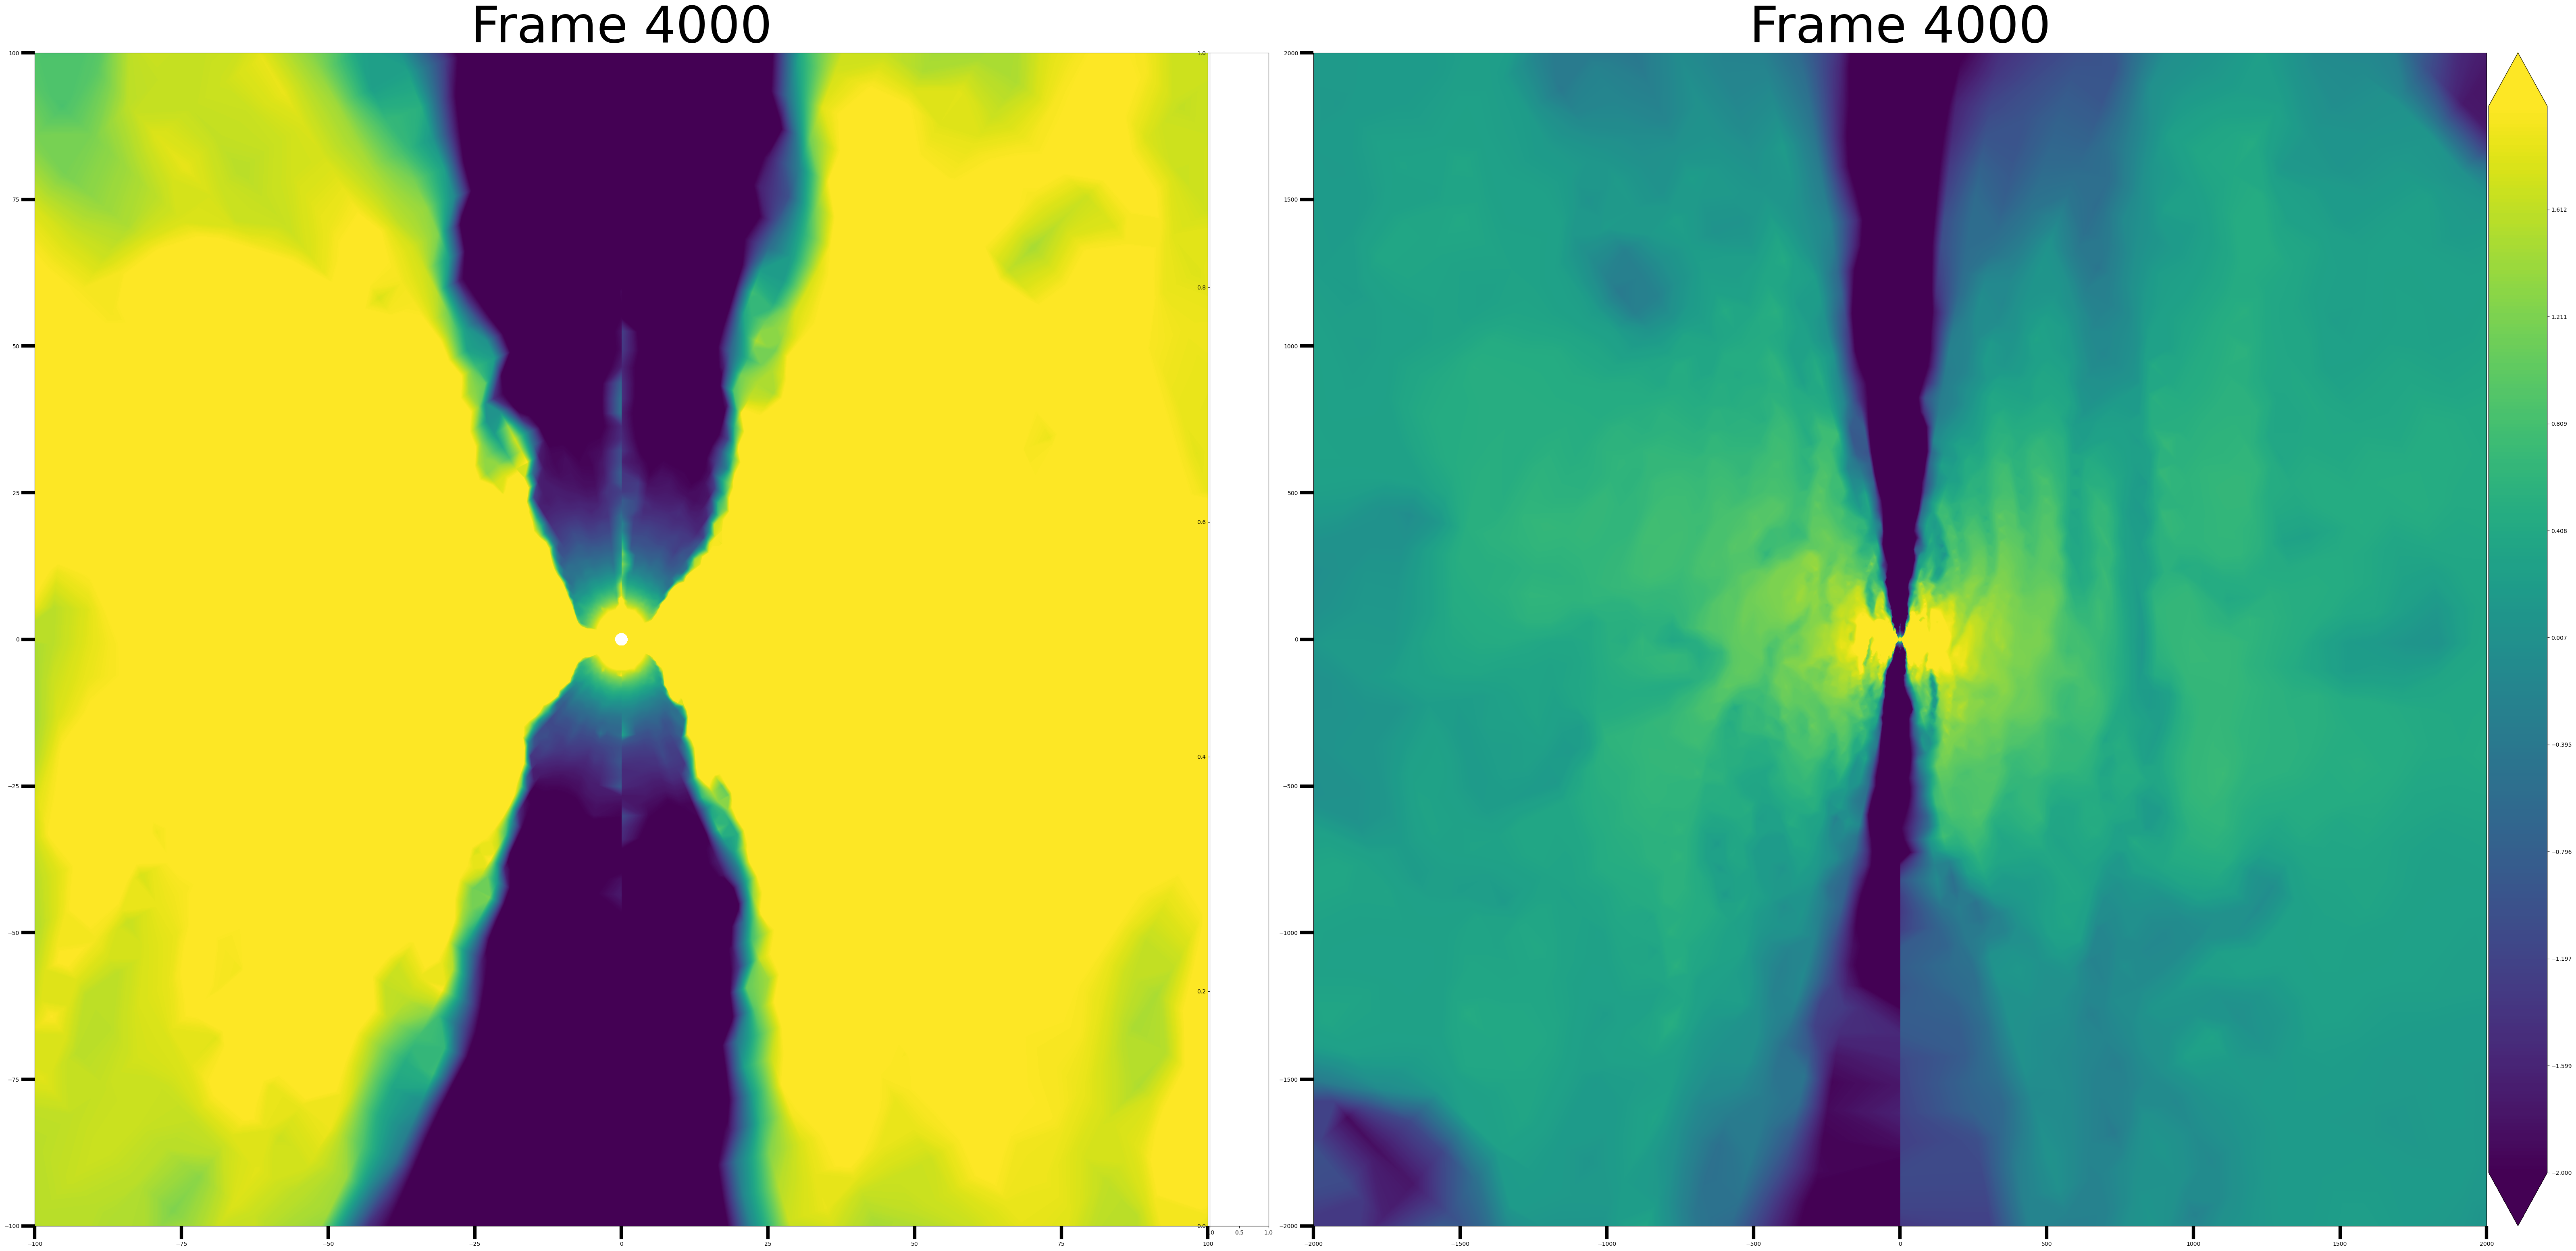

In [2]:
import os
dir = os.getenv('HOME')+'/bh'
os.chdir(dir)

from src.render import plot_frame

DATA_PATH = os.getenv('SCRATCH')+"/data.hdf5"

dump = 4000
# 
plot_frame(data_path=DATA_PATH, variable_name='log(rho)', dump_number=dump, save_path=None)

## Save Hard-to-Access Globals

In [ ]:
import os
dir = os.getenv('HOME')+'/bh'
os.chdir(dir)

np.save('utils/'+config['r_path'], r)
np.save('utils/'+config['h_path'], h)
np.save('utils/'+config['ph_path'], ph)
np.save('utils/'+config['block_path'], block)
np.save('utils/'+config['n_ord_path'], n_ord)


## Write to Disk

In [ ]:
import os
import numpy as np
import h5py
from tqdm import tqdm

# populate HDF5 file with data from source dumps
def write_dumps_to_hdf5(
        dumps_path:str, 
        data_path:str, 
        write_batch_size: int,
        start_dump: int, 
        num_dumps: int
    ):
    with h5py.File(data_path, "a") as f:
        rblock_new_ml()

        prog_bar = tqdm(range(start_dump, start_dump+num_dumps))
        for dump in prog_bar:
            if (dump % write_batch_size) == 0:
                data_batch_array = []
                label_batch_array = []

            rpar_new(dump)
            if dump == start_dump:
                rgdump_griddata(dumps_path)
            rdump_griddata(dumps_path, dump)

            # construct array
            new_data = np.expand_dims(np.concatenate((np.log(rho), ug, np.squeeze(uu[1:4], axis=1), np.squeeze(B[1:4], axis=1)), axis=0),0)
            new_label = np.array([[dump]])

            data_batch_array.append(new_data)
            label_batch_array.append(new_label)

            if (dump % write_batch_size) == (write_batch_size - 1) or (dump > start_dump+num_dumps - write_batch_size) :
                data_batch_array = np.stack(data_batch_array, axis=0)
                label_batch_array = np.stack(label_batch_array, axis=0)
            
                if dump == start_dump:
                    f.create_dataset('data', data=data_batch_array, compression="gzip", chunks=True, maxshape=(None,8,224,48,96))
                    f.create_dataset('dump_index', data=label_batch_array, compression="gzip", chunks=True, maxshape=(None,1))
                else:
                    f['data'].resize((f['data'].shape[0] + data_batch_array.shape[0]), axis=0)
                    f['data'][-data_batch_array.shape[0]:] = data_batch_array
                
                    f['dump_index'].resize((f['dump_index'].shape[0] + label_batch_array.shape[0]), axis=0)
                    f['dump_index'][-label_batch_array.shape[0]:] = label_batch_array

                    prog_bar.set_description(f"Dump {dump} written.")


# DUMPS_PATH is the source file for the dumps to save
DUMPS_PATH = '/pscratch/sd/l/lalakos/ml_data_rc300/reduced'
# DATA_PATH is where the organized HDF5 file will be saved
DATA_PATH = os.getenv('SCRATCH')+"/data.hdf5"

num_dumps = config['end_dump'] - config['start_dump']

# set to true to write to hdf5 file
writeToDisk = False
if writeToDisk:
    write_dumps_to_hdf5(
        dups_path = DUMPS_PATH, 
        data_path = DATA_PATH, 
        write_batch_size = 32,
        start_dump = config['start_dump'], 
        num_dumps = num_dumps
    )

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/global/common/software/nersc/pe/conda-envs/24.1.0/python-3.11/nersc-python/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_1663114/994636482.py", line 27, in <module>
    view_reconstruction(
  File "/global/u1/j/jackh/bh/src/render.py", line 93, in view_reconstruction
torch.OutOfMemoryError: CUDA out of memory. Tried to allocate 6.89 GiB. GPU 0 has a total capacity of 39.38 GiB of which 3.73 GiB is free. Process 924829 has 442.00 MiB memory in use. Including non-PyTorch memory, this process has 35.21 GiB memory in use. Of the allocated memory 34.31 GiB is allocated by PyTorch, and 411.40 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/sta

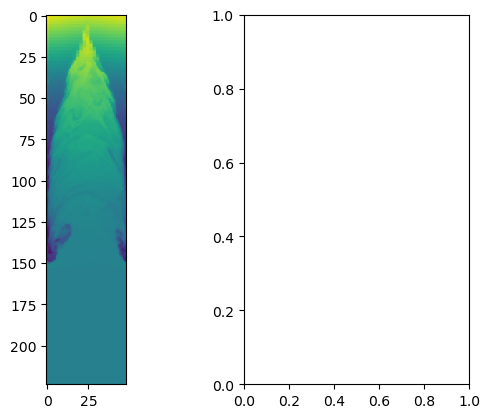

In [7]:
import os
import yaml
import torch
from src.models.vaes import VAE
from src.render import view_reconstruction

DATA_PATH = os.getenv('SCRATCH')+"/data.hdf5"
MODEL_PATH = os.getenv('HOME')+"/bh/src/models/checkpoints/vae_2025-11-26 16:56:53.891862_epoch_3.pth"


HOME_DIR = os.getenv('HOME')
with open(f'{HOME_DIR}/bh/config.yaml', 'r') as file: config = yaml.safe_load(file)

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = "cpu"
input_shape = (8,224,48,96)
LATENT_DIM = config['latent_dim']

# load model
model = VAE(
    input_shape=input_shape, 
    latent_dim=LATENT_DIM
).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()

view_reconstruction(
    data_path = DATA_PATH,
    model = model,
    variable_name = 'log(rho)', 
    dump_number = 4000
)